In [2]:
import pandas as pd
import numpy as np
import mne

full_eeg_df = pd.read_csv("thetaEEG_full_2back_-1580742246_20260616_152430.csv")
eeg_lsl_starttime = 313249.3180219 # NOT calibration complete
full_eeg_df["Time"] = full_eeg_df["Time"] + eeg_lsl_starttime
target_timestamp = np.array([1783460.6038521, 1783467.9537836, 1783475.2202884, 1783482.676686 ,1783493.0251028]) # when LIFU Sonicated
pre = 10
post = 10
windows = []
for idx, event in enumerate(target_timestamp): 
    mask = (full_eeg_df['Time'] >= (event - pre)) & (full_eeg_df['Time'] <= (event + post))
    window_df = full_eeg_df.loc[mask].copy()
    window_df["t_rel"] = window_df["Time"] - event 
    window_df["idx"] = idx
    windows.append(window_df)
#windows has 3 dataframes in one -- index them
first_data = windows[0]
first_data = first_data.drop(columns = ['t_rel', 'idx','Time'])
first_data

,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08


Creating RawArray with float64 data, n_channels=7, n_times=5000
    Range : 0 ... 4999 =      0.000 ...    19.996 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuati

C:\Users\jshin\AppData\Local\Temp\ipykernel_28236\220749044.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


<Figure size 1200x600 with 0 Axes>

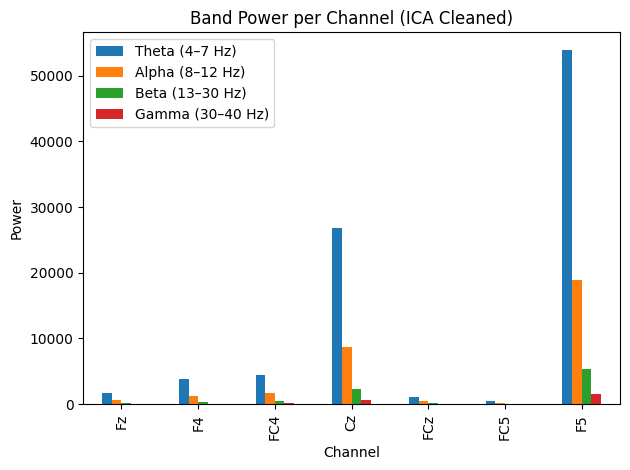

In [278]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# first_data: rows = samples, columns = 8 EEG channels
# 1. Clean and Load Data
df = pd.DataFrame(first_data.copy())
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(-200000.0, np.nan)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)
df = df.interpolate(method='linear', limit=5, limit_direction='both')
df = df.fillna(method='bfill').fillna(method='ffill')

# 2. MNE Array Building
sfreq = 250
data = df.values.T  # shape: (n_channels, n_samples)

# Mapping --> make it less manual
ch_names = [
    "Fz",   # 1
    "F4",   # 2
    "FC4",  # 3
    "Cz",   # 4
   # "F3",   # 5
    "FCz",  # 6
    "FC5",  # 7
    "F5"    # 8
]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# 3. ICA topography
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

# 4. Filtering
# 1–40 Hz is a good compromise for ICA + PSD
raw.filter(1., 40., fir_design='firwin')
raw.notch_filter(60.)
raw.filter(l_freq=1.0, h_freq=40.0, method='fir', fir_window='hamming')
raw.set_eeg_reference('average')

# 5. ICA
ica = mne.preprocessing.ICA(
    n_components= 0.99,
    random_state=97,
    max_iter='auto'
)
ica.fit(raw)

# # Inspect components:
# ica.plot_components()      # scalp maps
# ica.plot_sources(raw)      # time series

# After inspecting, set the components you want to remove:
ica.exclude = [0]  # don't know how to do this
raw_clean = ica.apply(raw.copy())

# 6. PSDs
psds, freqs = raw_clean.compute_psd(
    fmin=2,
    fmax=40,
    n_fft=512
).get_data(return_freqs=True)

# 7. Bandpower
def band_power(psds, freqs, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return psds[:, mask].mean(axis=1)

theta = band_power(psds, freqs, 4, 7)
alpha = band_power(psds, freqs, 8, 12)
beta  = band_power(psds, freqs, 13, 30)
gamma = band_power(psds, freqs, 30, 40)

# 8. Plotting
bands_df = pd.DataFrame({
    'Channel': ch_names,
    'Theta (4–7 Hz)': theta,
    'Alpha (8–12 Hz)': alpha,
    'Beta (13–30 Hz)': beta,
    'Gamma (30–40 Hz)': gamma
})

print(bands_df)

plt.figure(figsize=(12, 6))
bands_df.set_index('Channel').plot(kind='bar')
plt.ylabel('Power')
plt.title('Band Power per Channel (ICA Cleaned)')
plt.tight_layout()
plt.show()


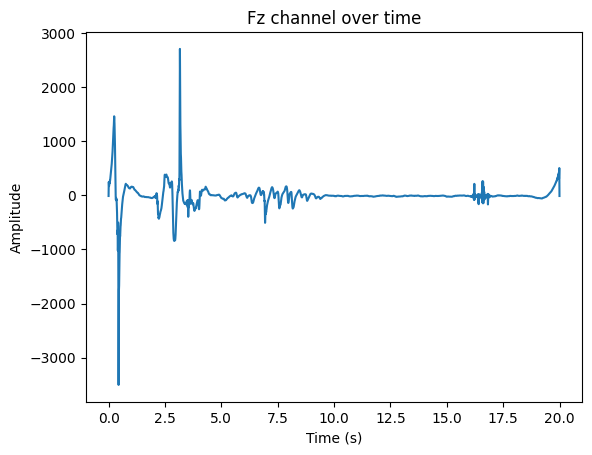

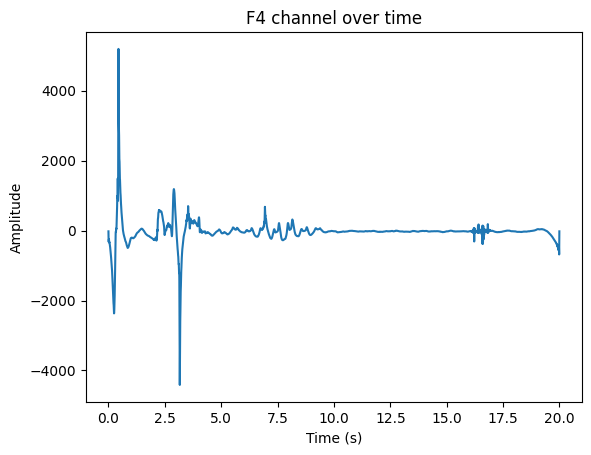

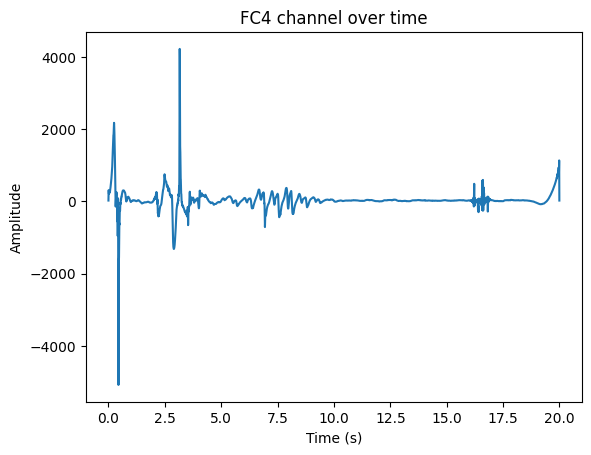

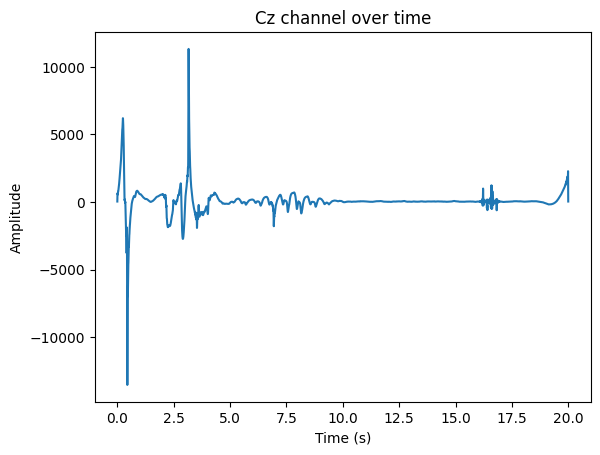

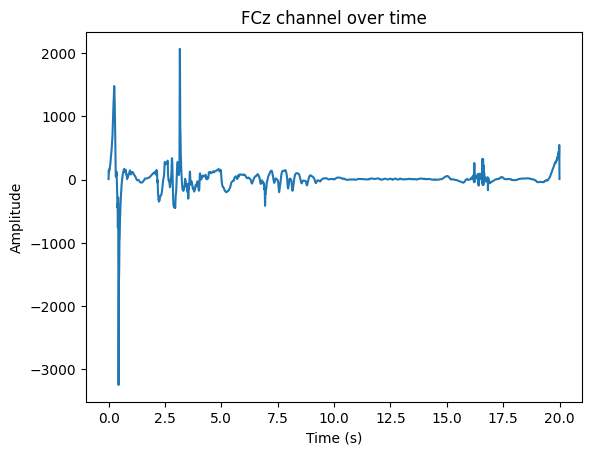

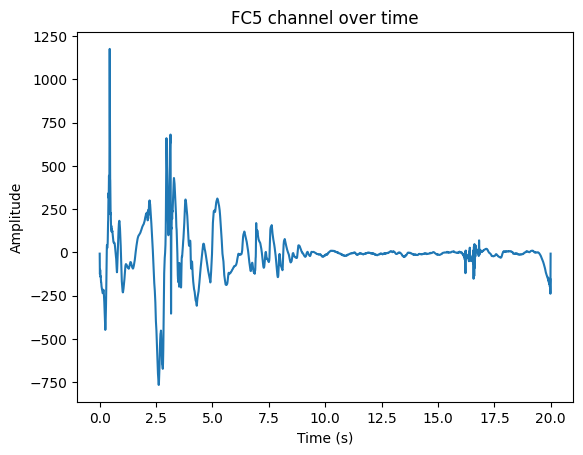

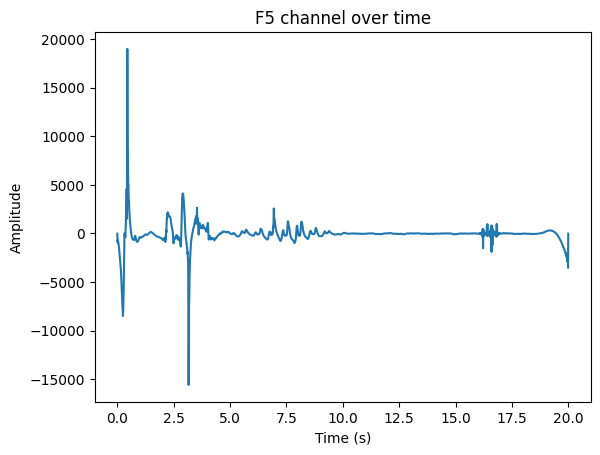

In [279]:
data = raw_clean.get_data()
for channel in raw.ch_names:
    channel_idx = raw.ch_names.index(channel)
    time_data = np.arange(0, 20, 1/250)  # adjust 500 to your sampling rate
    plt.plot(time_data, data[channel_idx])
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(f'{channel} channel over time')
    plt.show()

In [280]:
theta_pow = band_power(psds, freqs, 4, 7)
alpha_pow = band_power(psds, freqs, 8, 12)
theta_alpha_ratio = theta_pow / alpha_pow
theta_alpha_ratio

array([2.6378242 , 3.10759633, 2.67609501, 3.07491898, 2.0051262 ,
       4.34750928, 2.84555967])

In [281]:
import numpy as np

# amplitude threshold (µV)
amp_thresh = 150  # tweak as needed
eeg_filt = raw_clean.get_data().T
bad_amp = np.any(np.abs(eeg_filt) > amp_thresh, axis=1)

# gradient threshold (sudden jumps)
grad = np.diff(eeg_filt, axis=0, prepend=eeg_filt[[0], :])
grad_thresh = 50  # µV per sample
bad_grad = np.any(np.abs(grad) > grad_thresh, axis=1)

bad_samples = bad_amp | bad_grad


Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\jshin\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


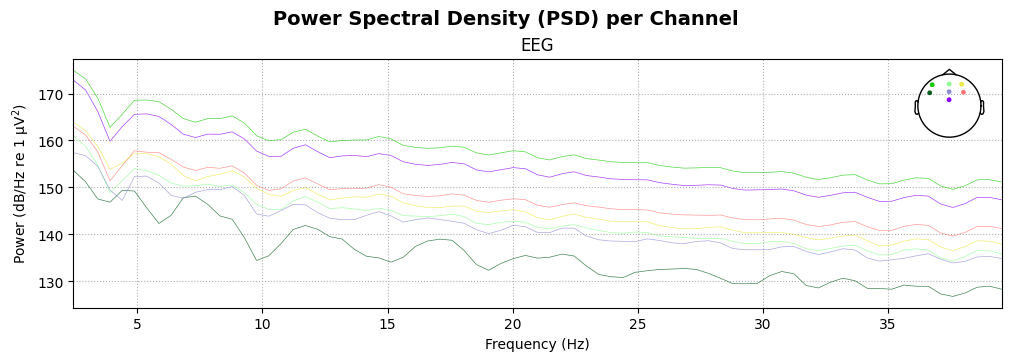

In [282]:
spectrum = raw_clean.compute_psd(fmin=2, fmax=40, n_fft=512)

# Plot the spectrum across all channels
fig = spectrum.plot(picks='all', spatial_colors=True, exclude='bads')

# Adjust the plot title and layout
fig.suptitle('Power Spectral Density (PSD) per Channel', fontsize=14, weight='bold')
plt.show()

In [321]:
# PSD DATA ANALYSIS
# Part 1: percent change pre and post trigger

fs = 250
prev = 10
posts = 10
pre_window = int(prev*fs)
post_window = int(posts* fs)
eeg_filt = pd.DataFrame(raw_clean.get_data().copy()).T
#target_timestamp
pre_segments = []
post_segments  = []
pre_segments.append(eeg_filt.iloc[:pre_window])
post_segments.append(eeg_filt.iloc[post_window:])

In [322]:
from scipy.signal import welch
import numpy as np

def compute_psd(seg):
    f, psd = welch(seg, fs=fs, nperseg=fs, axis=0)
    return f, psd  # psd shape: freqs × channels
pre_psds  = []
post_psds = []

for pre, post in zip(pre_segments, post_segments):
    f, pre_psd  = compute_psd(pre)
    _, post_psd = compute_psd(post)
    pre_psds.append(pre_psd)
    post_psds.append(post_psd)
pre_psd_mean  = np.mean(pre_psds, axis=0)
post_psd_mean = np.mean(post_psds, axis=0)


In [329]:
percent_change_psd = (post_psd_mean - pre_psd_mean) / pre_psd_mean * 100
percent_change_psd = pd.DataFrame(percent_change_psd)
percent_change_psd.head(40)

,0,1,2,3,4,5,6
0,-98.994087,-99.379239,-95.741447,-98.682904,-94.843834,-98.970146,-97.410033
1,-98.900446,-99.357264,-95.582982,-98.755797,-96.289650,-99.347347,-97.749097
2,-99.866815,-99.887884,-99.523226,-99.818338,-99.457835,-99.708292,-99.715691
3,-99.810315,-99.865148,-99.578907,-99.788189,-99.670401,-99.462282,-99.722750
4,-99.773217,-99.850603,-99.695468,-99.762628,-99.719622,-99.667844,-99.757481
5,-99.950664,-99.953073,-99.862984,-99.940801,-99.719888,-99.851679,-99.909299
6,-99.852019,-99.878716,-99.723014,-99.836169,-99.597791,-99.746592,-99.778125
7,-99.394438,-99.456253,-99.051154,-99.187146,-99.024143,-99.525420,-99.103306
8,-99.478967,-99.432674,-99.217953,-99.227233,-99.145339,-99.555439,-99.187257
9,-99.723651,-99.714890,-99.620407,-99.650304,-99.531112,-99.679163,-99.623420


In [331]:
def band_power(psd, freqs, f_lo, f_hi):
    idx = (freqs >= f_lo) & (freqs <= f_hi)
    return np.trapz(psd[idx, :], freqs[idx], axis=0)
# Theta (4–7 Hz)
pre_theta  = band_power(pre_psd_mean,  f, 4, 7)
post_theta = band_power(post_psd_mean, f, 4, 7)

# Alpha (8–12 Hz)
pre_alpha  = band_power(pre_psd_mean,  f, 8, 12)
post_alpha = band_power(post_psd_mean, f, 8, 12)

# Beta (13–30 Hz)
pre_beta  = band_power(pre_psd_mean,  f, 13, 30)
post_beta = band_power(post_psd_mean, f, 13, 30)

# Gamma (30-40Hz)
pre_gamma = band_power(pre_psd_mean,  f, 30, 40)
post_gamma = band_power(post_psd_mean, f, 30, 40)


theta_pct = (post_theta - pre_theta) / pre_theta * 100
alpha_pct = (post_alpha - pre_alpha) / pre_alpha * 100
beta_pct  = (post_beta  - pre_beta ) / pre_beta  * 100
gamma_pct =  (post_gamma  - pre_gamma ) / pre_gamma  * 100

bands_pct_df = pd.DataFrame({
    "Theta %Δ": theta_pct,
    "Alpha %Δ": alpha_pct,
    "Beta %Δ":  beta_pct,
    "Gamma %Δ" : gamma_pct,
})
bands_pct_df.index = [f"Ch{i+1}" for i in range(7)]
bands_pct_df


,Theta %Δ,Alpha %Δ,Beta %Δ,Gamma %Δ
Ch1,-99.809877,-99.677486,-99.072105,-85.671613
Ch2,-99.848052,-99.679034,-99.207202,-86.142575
Ch3,-99.671346,-99.545663,-98.647610,-81.721434
Ch4,-99.778584,-99.577398,-98.826056,-81.587858
Ch5,-99.582405,-99.500402,-98.935178,-82.800781
Ch6,-99.736197,-99.645529,-98.667320,-82.177087
Ch7,-99.729290,-99.552237,-98.753194,-81.458030
